<div style="text-align: center;">

  <span style="color: green; font-size: 2em; font-weight: bold; display: block;">
    Analyse des sentiments
  </span><br><br>

  <span style="font-weight: bold; display: block;">
    Réalisé par:
  </span><br>

  <span style="display: block;">
    Nouboussi Gnintedem Lucie Marimar
  </span><br>

  <span style="font-weight: bold; display: block;">
    Sous l'encadrement de:
  </span><br>

  <span style="display: block;">
    Mr. Christopher Kermorvant
  </span><br>

</div>

<div style="margin-top: 20px; margin-bottom: 20px; border-bottom: 2px solid #006400;"></div>

##  <span style="color:green; font-size:1em; font-weight:bold;"> Résumé</span>

Ce projet explore l’utilisation de différentes méthodes de représentation des mots (embeddings et LLMs) pour améliorer les performances de modèles de classification de texte sur le jeu de données ACL IMDB. L’objectif est de sélectionner une représentation optimale des mots. Nous commençons par nettoyer les données avec des expressions régulières, extrayons des tokens que nous transformons en lemmes, puis utilisons la méthode TF-IDF (term frequency-inverse document frequency) pour pondérer ces lemmes. Cette approche, bien que simple, présente des limites : elle ignore l’ordre des mots et génère une représentation éparse, pouvant entraîner des problèmes de dimensionnalité et de complexité computationnelle. Pour pallier ces défauts, nous testons Word2Vec, une méthode dense projetant chaque mot dans un vecteur de taille choisie, basée sur l’approche skip-gram et tenant compte du contexte local, ainsi que BERT, un LLM capturant un contexte global grâce à son architecture de transformeur bidirectionnelle.

Une fois les mots représentés, nous appliquons des classificateurs tels que Naive Bayes, Régression Logistique, SVM, XGBoost et ElasticNet, et utilisons un modèle pré-entraîné BERT pour évaluer les gains de performance. Les résultats sont évalués avec la précision, le rappel, le F1-score et l’Accuracy. Étant donné l’équilibre des classes (50 % positif, 50 % négatif), l’Accuracy est une métrique pertinente, complétée par l’analyse des courbes ROC.

###  <span style="color:green; font-size:1em; font-weight:bold;"> Performances du modèle en utilisant TF-IDF</span>


Le tableau ci-dessous présente les performances des modèles de classification sur l’ensemble de test avec la méthode TF-IDF.

| Modèle              | Accuracy | F1-score | Précision | Rappel |
|---------------------|----------|----------|-----------|--------|
| Naive Bayes         | 0.8247   | 0.8138   | 0.8679    | 0.7661 |
| Régression Logistique | 0.8527 | 0.8558 | 0.8379 | 0.8745 |
| SVM                 | 0.8684   | 0.8715   | 0.8515    | 0.8924 |
| XGBoost             | 0.8358   | 0.8401   | 0.8188    | 0.8626 |
| ElasticNet          | 0.8784   | 0.8783   | 0.8791    | 0.8776 |

Régression Logistique, SVM et ElasticNet affichent des performances compétitives, avec ElasticNet en tête (Accuracy : 0,8784, F1-score : 0,8783), tandis que Naive Bayes (Accuracy : 0,8247) et XGBoost (Accuracy : 0,8358) sont légèrement en retrait. L’AUC de ElasticNet atteint 0,95, confirmant sa robustesse. La courbe ROC est disponible ci-dessous.

###  <span style="color:green; font-size:1em; font-weight:bold;"> Performances du modèle en utilisant Word2Vec</span>


Le tableau ci-dessous présente les performances des modèles sur l’ensemble de test avec la méthode Word2Vec.

| Modèle              | Accuracy | F1-score | Précision | Rappel |
|---------------------|----------|----------|-----------|--------|
| Naive Bayes         | 0.7035   | 0.6943   | 0.7164    | 0.6736 |
| Régression Logistique | 0.8261 | 0.8265 | 0.8246 | 0.8285 |
| SVM                 | 0.8304   | 0.8312   | 0.8272    | 0.8351 |
| XGBoost             | 0.8082   | 0.8085   | 0.8072    | 0.8098 |
| ElasticNet          | 0.8270   | 0.8274   | 0.8253    | 0.8296 |

Les performances avec Word2Vec sont globalement inférieures à celles de TF-IDF, avec SVM en tête (Accuracy : 0,8304, F1-score : 0,8312), suivi de près par ElasticNet (Accuracy : 0,8270). Naive Bayes (Accuracy : 0,7035) reste le moins performant, tandis que l’AUC de SVM atteint 0,91. Cette différence peut s’expliquer par un réglage suboptimal des hyperparamètres de Word2Vec. La courbe ROC est disponible ci-dessous.

### <span style="color:green; font-size:1em; font-weight:bold;"> Performances du modèle en utilisant BERT</span>

Le tableau ci-dessous présente les performances du modèle BERT sur l’ensemble de test.

| Modèle | Accuracy | F1-score | Précision | Rappel |
|--------|----------|----------|-----------|--------|
| BERT   | 0.8908   | 0.8879   | 0.9115    | 0.8656 |

BERT affiche une performance solide sur le test (Accuracy : 0,8908, F1-score : 0,8879), avec une précision élevée (0,9115) mais un rappel légèrement plus faible (0,8656). Cependant, son AUC de 0,89 est inférieur à celui de TF-IDF (0,95) et comparable à Word2Vec (0,91), suggérant un surajustement (AUC entraînement : 0,99) qui limite son avantage dans cette configuration. La courbe ROC est disponible ci-dessous.

### Notes
- Les valeurs sont tirées des données de test fournies pour refléter la généralisation des modèles.
- Les courbes ROC peuvent être incluses avec des images correspondantes (`courbes_roc_tfidf.png`, `courbes_roc_word2vec.png`, `courbes_roc_bert.png`) dans votre document.

 <div style="text-align:center;">
  <span style="color:green; font-size:2em; font-weight:bold;">Introduction </span><br><br>
  </div>


Le jeu de données ACL IMDB (souvent appelé aussi aclImdb ou IMDB Movie Reviews) est un jeu de 50 000 critiques de films recueillies sur le site IMDB, spécialement conçu pour la classification de sentiment (positif/négatif). Il a été introduit dans l’article de Andrew L. Maas et al. (2011), Learning Word Vectors for Sentiment Analysis. <br>

La première étape de l'analyse consiste à charger ces données, les explorer et les prétraiter. Dans la cellule suivante, les données train négatives sont chargées. <br>



La fonction `input_docs`permet de charger les données. Elle utilise les expressions régulières pour supprimer les balises HTML et faire des nettoyage supplémentaires comme la segmentation de la chaîne sur tout ce qui n'est pas une lettre (a-z). 

La fonction `freq` permet la représentation des données en utilisant un dictionnaire qui contient les mots et leur fréquence. Ceci nous donne une première représentation des données qui facilitera l'exploration et le prétraitement.

# <span style="color:green; font-size:1em; font-weight:bold;"> I - Importation et installation des packages</span>

Pour plus de clarté et de lisibilité du code,  l'ensemble des imports nécessaires dans un fichier distinct "functions.py". <br> Ce dernier est ainsi appelé au tout début. Si des ajouts, suppressions ou mises à jour des dépendances sont requises, ces dernières sont faites simplement dans le fichier "functions.py".

In [43]:
# Obtenir le répertoire de travail courant (dans un notebook, par exemple)
import os
current_dir = os.getcwd()


#print("Current working directory: {0}".format(current_dir))

exec(open(os.path.join(current_dir, "functions.py")).read())

# <span style="color:green; font-size:1em; font-weight:bold;"> II - Préparation de données</span>

### <span style="color:green; font-size:1em; font-weight:bold;"> Chargement des données : train et test </span>

In [44]:
# URL du dataset
url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"

# Télécharger le fichier .tar.gz
response = requests.get(url, stream=True)
response.raise_for_status()

# Ouvrir le fichier tar directement depuis la mémoire
tar_file = tarfile.open(fileobj=io.BytesIO(response.content), mode="r:gz")

# lister tous les fichiers POS et neg dans le dossier train
train_pos_files = [member for member in tar_file.getmembers() 
                   if member.name.startswith("aclImdb/train/pos/") and member.name.endswith(".txt")]
train_neg_files = [member for member in tar_file.getmembers() 
                   if member.name.startswith("aclImdb/train/neg/") and member.name.endswith(".txt")]
## Lire le contenu texte et le nettoyer 
train_pos_texts = f.clean_texts(f.extract_texts_from_tar(tar_file, train_pos_files))
train_neg_texts =  f.clean_texts(f.extract_texts_from_tar(tar_file, train_neg_files))

# lister tous les fichiers POS et neg dans le dossier test
test_pos_files = [member for member in tar_file.getmembers() 
                   if member.name.startswith("aclImdb/test/pos/") and member.name.endswith(".txt")]
test_neg_files = [member for member in tar_file.getmembers() 
                   if member.name.startswith("aclImdb/test/neg/") and member.name.endswith(".txt")]


## Lire le contenu texte et le nettoyer 
test_pos_texts =  f.clean_texts(f.extract_texts_from_tar(tar_file, test_pos_files))
test_neg_texts =  f.clean_texts(f.extract_texts_from_tar(tar_file, test_neg_files))





# Lire le contenu du premier fichier POS
first_pos_file = train_pos_files[0]
file_obj = tar_file.extractfile(first_pos_file)
text = file_obj.read().decode("utf-8")

print("Nom du fichier :", first_pos_file.name)
print("Contenu (début) :")
print(text[:500])  # Affiche les 500 premiers caractères


Nom du fichier : aclImdb/train/pos/127_7.txt
Contenu (début) :
Zentropa has much in common with The Third Man, another noir-like film set among the rubble of postwar Europe. Like TTM, there is much inventive camera work. There is an innocent American who gets emotionally involved with a woman he doesn't really understand, and whose naivety is all the more striking in contrast with the natives.<br /><br />But I'd have to say that The Third Man has a more well-crafted storyline. Zentropa is a bit disjointed in this respect. Perhaps this is intentional: it is 



### <span style="color:green; font-size:1em; font-weight:bold;"> Distribution des données d'entrainement</span>

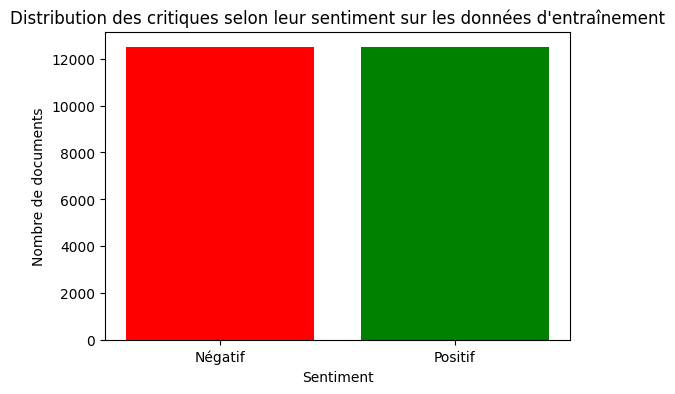

In [45]:
nb_negatifs = len(train_neg_files)
nb_positifs = len(train_pos_files)

labels = ['Négatif', 'Positif']
counts = [nb_negatifs, nb_positifs]

plt.figure(figsize=(6,4))
plt.bar(labels, counts, color=['red', 'green'])
plt.xlabel("Sentiment")
plt.ylabel("Nombre de documents")
plt.title("Distribution des critiques selon leur sentiment sur les données d'entraînement")
plt.show()

La cellule précédente permet de visualiser la distribution des données d'entrainement. Il s'avère que les données sont équilibrées. Ainsi, l'équilibrage des données n'est pas necessaire. Par conséauent, utiliser les méthodes telles que la précision, le rappel et le F1-score pour évaluer les performances de nos modèles est approprié.

### <span style="color:green; font-size:1em; font-weight:bold;"> Transformation des données d'entrainement</span>

<div style="margin-left: 20px;">
    <span style="font-weight:bold;"> - </span> Les données d'entrainement sont crées en combinant les données positives et négatives. <br>
    </div>


La fonction `word_vector` permet non seulement de charger les données positives et négatives, les charge en listes de mots, mais aussi traite les mots tels que `don t`, `isn t` etc. L'idée est de rechercher tous les pattern qui se termine par `n` suivi par un espace et `t` suivi d'un espace ou de la fin de la chaîne. <br>
Ensuite le remplace par une forme contractée. Cette forme contractée sera ensuite transformée sous forme négative en utilisant `contractions`. Par exemple, `don t` sera transformé en `do not`. <br>

La variable cible y fabrique une liste de labels :

- 0 pour négatif (autant que de critiques négatives)

- 1 pour positif (autant que de critiques positives)

La visualisation des données qui est faite ultérieurement permettra de faire ces traitements.

In [46]:
docs_train = word_vectors(train_neg_texts,train_pos_texts)

# Création des labels
y_train = [0]*len(train_neg_files) + [1]*len(train_pos_files)

print(len(docs_train), len(y_train),)

25000 25000



### <span style="color:green; font-size:1em; font-weight:bold;"> Distribution des données de test</span>

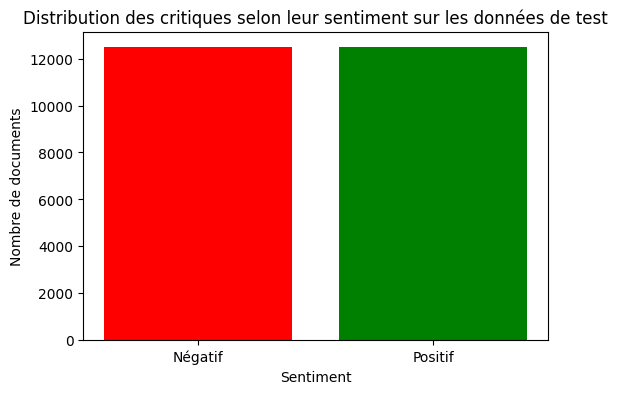

In [47]:
nb_negatifs = len(test_neg_files)
nb_positifs = len(test_pos_files)

labels = ['Négatif', 'Positif']
counts = [nb_negatifs, nb_positifs]

plt.figure(figsize=(6,4))
plt.bar(labels, counts, color=['red', 'green'])
plt.xlabel("Sentiment")
plt.ylabel("Nombre de documents")
plt.title("Distribution des critiques selon leur sentiment sur les données de test")
plt.show()

### <span style="color:green; font-size:1em; font-weight:bold;"> Transformation des données de test</span>

In [48]:
docs_test= word_vectors(test_neg_texts,test_pos_texts)
# Création des labels
y_test = [0]*len(test_neg_texts) + [1]*len(test_pos_texts)

print(len(docs_test), len(y_test))

25000 25000


##### quelques statistiques

In [ ]:
X_train = train_neg_texts+train_pos_texts
X_test = test_neg_texts+test_pos_texts

Longueur moyenne des critiques : 234.18 mots (écart-type : 173.51)
Longueur moyenne des critiques positives : 239.62 mots
Longueur moyenne des critiques négatives : 234.11 mots
Taille du vocabulaire après prétraitement : 99420 tokens uniques


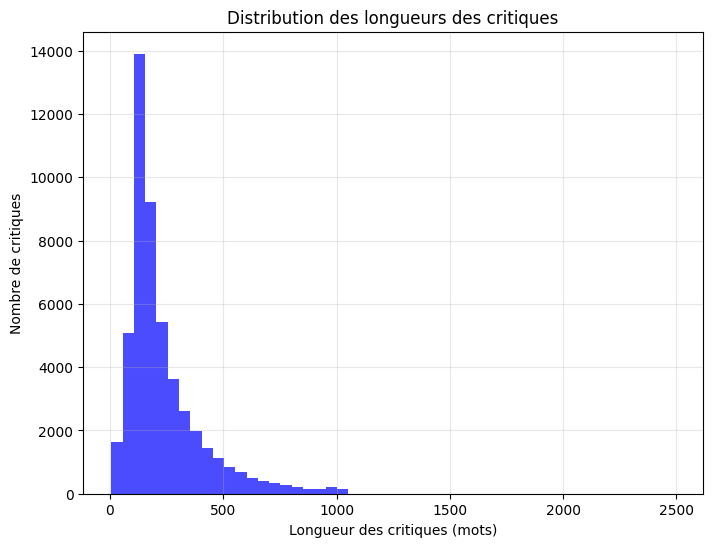

In [108]:
# Calcul des longueurs des critiques
train_lengths = [len(text.split()) for text in X_train]
test_lengths = [len(text.split()) for text in X_test]
all_lengths = train_lengths + test_lengths

# Longueurs par classe (positif vs négatif)
positive_lengths = [len(X_train[i].split()) for i in range(len(X_train)) if y_train[i] == 1]
negative_lengths = [len(X_train[i].split()) for i in range(len(X_train)) if y_train[i] == 0]

# Statistiques descriptives
mean_length = np.mean(all_lengths)
std_length = np.std(all_lengths)
mean_positive = np.mean(positive_lengths)
mean_negative = np.mean(negative_lengths)

# Taille du vocabulaire
all_words = ' '.join(X_train + X_test).split()
vocab_size = len(set(all_words))

# Affichage des résultats
print(f"Longueur moyenne des critiques : {mean_length:.2f} mots (écart-type : {std_length:.2f})")
print(f"Longueur moyenne des critiques positives : {mean_positive:.2f} mots")
print(f"Longueur moyenne des critiques négatives : {mean_negative:.2f} mots")
print(f"Taille du vocabulaire après prétraitement : {vocab_size} tokens uniques")

# Visualisation de la distribution des longueurs
plt.figure(figsize=(8, 6))
plt.hist(all_lengths, bins=50, alpha=0.7, color='blue')
plt.xlabel('Longueur des critiques (mots)')
plt.ylabel('Nombre de critiques')
plt.title('Distribution des longueurs des critiques')
plt.grid(alpha=0.3)
plt.savefig('distribution_longueur_critiques.png')
plt.show()

# <span style="color:green; font-size:1em; font-weight:bold;"> III - Visualisation des mots de critiques </span>

Le graphique suivant visualise les mots des critiques négatifs et positifs suivant leur fréquence. <br>
Par exemple, les mots `audience`, `source` sont les mots les plus fréquents dans les critiques négatives.  <br>

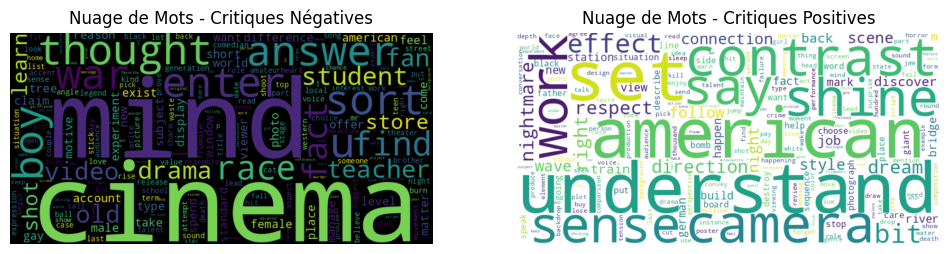

In [49]:

# Générer un word cloud pour les mots négatifs
negative_words = " ".join(freq(train_neg_texts).keys())  # Concaténer tous les mots négatifs
wordcloud_neg = WordCloud(width=800, height=400, background_color="black").generate(negative_words)

# Générer un word cloud pour les mots positifs
positive_words = " ".join(freq(train_pos_texts).keys())  # Concaténer tous les mots positifs
wordcloud_pos = f.WordCloud(width=800, height=400, background_color="white").generate(positive_words)

# Afficher les word clouds
plt.figure(figsize=(12, 6))

# Word cloud des critiques négatives
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_neg, interpolation="bilinear")
plt.axis("off")
plt.title("Nuage de Mots - Critiques Négatives")

# Word cloud des critiques positives
plt.subplot(1, 2, 2)
plt.imshow(wordcloud_pos, interpolation="bilinear")
plt.axis("off")
plt.title("Nuage de Mots - Critiques Positives")

plt.show()


#### <span style="color:green; font-size:1em; font-weight:bold;"> Commentaire</span>

Les nuages de mots montrent les termes les plus fréquents dans les critiques de films négatives et positives. <br> <br> Dans les critiques négatives, les mots dominants comme cinema, mind, war, student ou teacher traduisent une approche plus analytique, souvent centrée sur des aspects critiques ou techniques du film. On y perçoit une certaine distance ou insatisfaction. <br> <br> Par contre, les critiques positives mettent en avant des mots comme understand, shine, effect, camera ou dream, soulignant une appréciation de l’expérience esthétique, émotionnelle et narrative.<br> <br>  Cette opposition montre que les critiques négatives se concentrent davantage sur le fond et les limites perçues du film, tandis que les critiques positives valorisent l’impact sensoriel, artistique et émotionnel de l’œuvre.

<br>
<br>
Une deuxième visualisation permet de vérifier que les éléments qui sont les plus fréquents sont les prépositions, les articles et les pronoms.

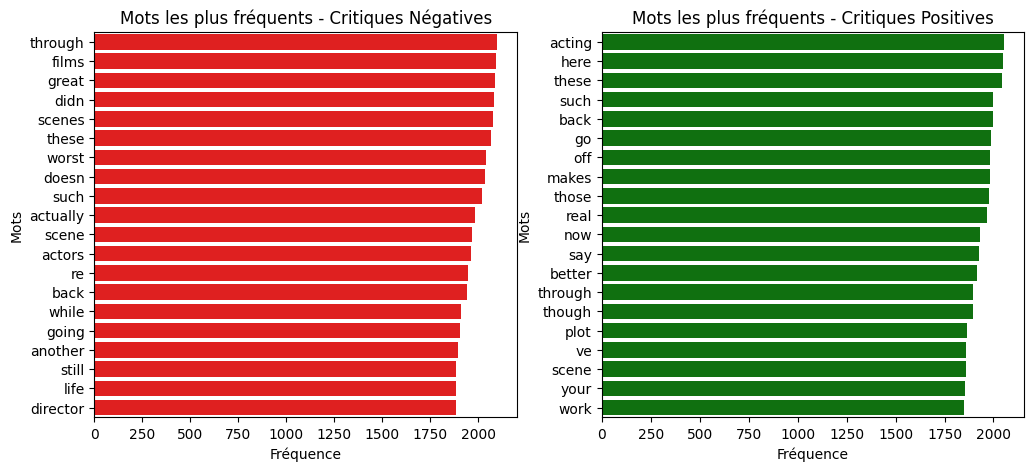

In [50]:


# Trier les mots les plus fréquents
top_neg = sorted(freq(train_neg_texts).items(), key=lambda x: x[1], reverse=True)[:20]
top_pos = sorted(freq(train_pos_texts).items(), key=lambda x: x[1], reverse=True)[:20]

# Extraire les données pour l'affichage
words_neg, freq_neg = zip(*top_neg)
words_pos, freq_pos = zip(*top_pos)

# Afficher les histogrammes
plt.figure(figsize=(12, 5))

# Histogramme des mots négatifs
plt.subplot(1, 2, 1)
f.sns.barplot(x=list(freq_neg), y=list(words_neg), color="red")
plt.xlabel("Fréquence")
plt.ylabel("Mots")
plt.title("Mots les plus fréquents - Critiques Négatives")

# Histogramme des mots positifs
plt.subplot(1, 2, 2)
f.sns.barplot(x=list(freq_pos), y=list(words_pos), color="green")
plt.xlabel("Fréquence")
plt.ylabel("Mots")
plt.title("Mots les plus fréquents - Critiques Positives")

plt.show()


#### <span style="color:green; font-size:1em; font-weight:bold;"> Commentaire</span>
Dans les critiques négatives, on remarque une présence importante de mots factuels et descriptifs tels que through, films, scenes, actors, director, ou encore worst, ce dernier traduisant explicitement un jugement négatif. <br> <br> D'autres mots comme didn, doesn, actually et still peuvent également refléter une insatisfaction ou une réserve. <br> <br>

En revanche, dans les critiques positives, bien que certains mots soient neutres ou partagés (scene, back, such, through), on observe aussi des termes à connotation valorisante tels que better, real, makes, plot, work ou acting.  <br> <br>

L’usage fréquent de mots partagés dans les deux types de critiques indique aussi que le contexte et l’orientation sémantique globale déterminent la tonalité, plus que les mots eux-mêmes.

### <span style="color:green; font-size:1em; font-weight:bold;"> Extraction des différentes entités sur l'ensemble des données d'entrainement</span>



Les prochaines cellules présenteront les étapes suivantes:
 
 - extraction les entités nommées des chaque token ou mot de chaque critique;
 - visualisation les entités pour évaluer quelles sont les entités pertinentes cette analyse de sentiment.

In [51]:
pos_counts, tokens_by_pos = pos_tag_docs(docs_train)


In [52]:
print(pos_counts)

Counter({'NOUN': 1213730, 'VERB': 738762, 'DET': 640196, 'ADP': 617334, 'PRON': 600005, 'ADJ': 529144, 'AUX': 382409, 'ADV': 373926, 'CCONJ': 228969, 'PROPN': 217422, 'PART': 181696, 'SCONJ': 148477, 'NUM': 35568, 'INTJ': 13018, 'X': 4826, 'PUNCT': 114, 'SYM': 113})


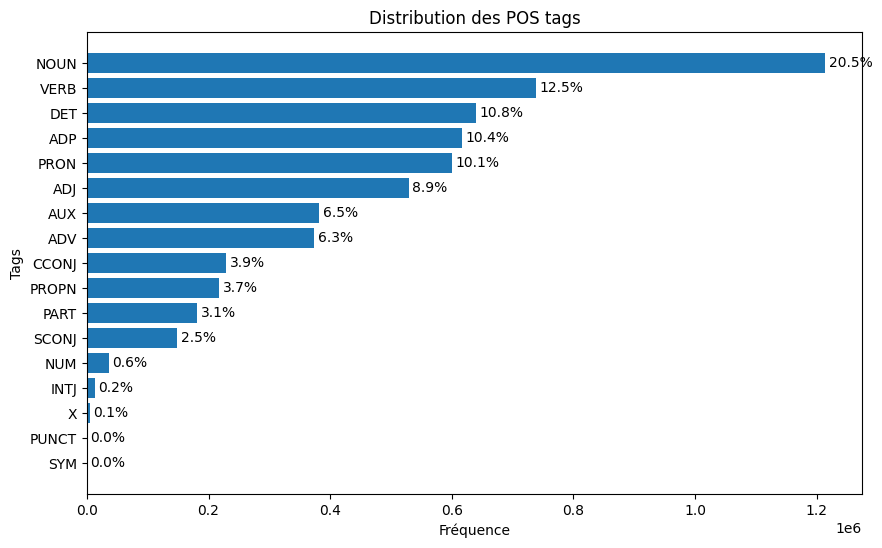

In [53]:


# Récupération des tags et de leurs fréquences, triés par ordre décroissant
tags, freqs = zip(*pos_counts.most_common())
total = sum(freqs)

plt.figure(figsize=(10, 6))
bars = plt.barh(tags, freqs)
plt.xlabel("Fréquence")
plt.ylabel("Tags")
plt.title("Distribution des POS tags")
plt.gca().invert_yaxis()  # Affiche le tag le plus fréquent en haut

# Ajout des pourcentages sur chaque barre
for bar in bars:
    width = bar.get_width()
    percent = width / total * 100
    plt.text(width + total * 0.001, bar.get_y() + bar.get_height()/2,
             f"{percent:.1f}%", va='center', ha='left')

plt.show()


#### <span style="color:green; font-size:1em; font-weight:bold;"> Commentaire</span>

Cette distribution permet de mieux comprendre la structure linguistique du texte et d’orienter le traitement automatique du langage en mettant l'accent sur les catégories les plus porteuses de sens.

Ce graphique montre que les noms (NOUN) sont les plus fréquents dans le corpus, représentant 20,5 % des mots, suivis des verbes (VERB), déterminants (DET), et prépositions (ADP), ce qui indique un style descriptif et narratif typique des critiques de films. 

La forte présence de pronoms (PRON), adjectifs (ADJ) et adverbes (ADV) montre également une  caractéristique des opinions personnelles. 

In [54]:
nouns_counter = tokens_by_pos["NOUN"]
print(nouns_counter.most_common(10))

[('movie', 43974), ('film', 39738), ('time', 12715), ('story', 11984), ('people', 9291), ('way', 7634), ('movies', 7556), ('characters', 7148), ('character', 6973), ('films', 6866)]


### <span style="color:green; font-size:1em; font-weight:bold;"> Exemple : Visualisation des noms les plus fréquents.</span>

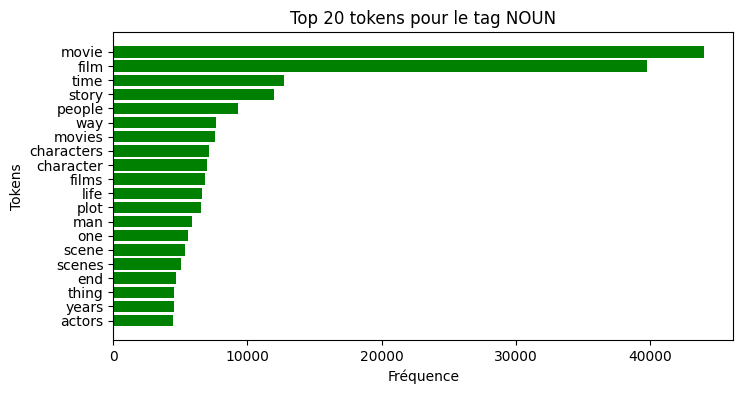

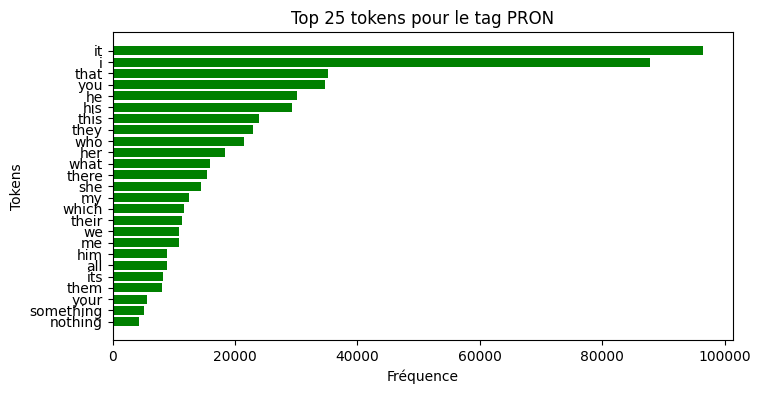

In [55]:
# Exemple : visualiser les noms les plus fréquents
plot_top_tokens_for_tag(tokens_by_pos, "NOUN", top_n=20)

# Exemple : visualiser les noms les plus fréquents
plot_top_tokens_for_tag(tokens_by_pos, "PRON", top_n=25)


#### <span style="color:green; font-size:1em; font-weight:bold;"> Commentaire</span>
La figure suivante montre que le mot le plus fréquent dans les données train est `movie` suivi de `film`. 

Il faut aussi noté que movie et movies sont considérés comme deux mots différents. Il en est de même pour characters et character. C'est pourquoi nous allons traiter le texte en utilisant une lemmatisation.

# <span style="color:green; font-size:1em; font-weight:bold;"> Iv- Lemmatisation des données.</span>


**La lemmatisation** consiste à transformer les mots en leur forme canonique. <br>
Par exemple, les mots `running`, `ran` et `run` seront transformés en `run`. <br> <br>

La cellule suivante permet de lemmatiser les données et d'exclure des données les mots qui sont des stop words qui proviennent des entités nommées `SYM`, `PUNCT`, `X`, `AUX`, et `PRON`.

### <span style="color:green; font-size:1em; font-weight:bold;">  Lematization des données d'entrainement</span>

In [56]:
# Préparer la liste de textes en joignant les tokens de chaque document
docs_train_texts = [" ".join(tokens) for tokens in docs_train]

# Utiliser nlp.pipe pour traiter les documents en lots
lemmatized_docs = [None] * len(docs_train_texts)
for i, doc in enumerate(nlp.pipe(docs_train_texts, batch_size=50
                                 ,n_process=4)):
    lemmatized_docs[i] = [token.lemma_ for token in doc if token.pos_ not in {"SYM", "PRON", "X","PUNCT","AUX"}]
    

# Affichage du résultat
for i, (original, lemmatized) in enumerate(zip(docs_train_texts, lemmatized_docs)):
    print(f"Document {i+1}:")
    print("Original :", original)
    print("Lemmatized :", lemmatized)
    print()
    break


Document 1:
Original : i rented i am curious yellow from my video store because of all the controversy that surrounded it when it was first released in i also heard that at first it was seized by you s customs if it ever tried to enter this country therefore being a fan of films considered controversial i really had to see this for myself the plot is centered around a young swedish drama student named lena who wants to learn everything she can about life in particular she wants to focus her attentions to making some sort of documentary on what the average swede thought about certain political issues such as the vietnam war and race issues in the united states in between asking politicians and ordinary denizens of stockholm about their opinions on politics she has sex with her drama teacher classmates and married men what kills me about i am curious yellow is that years ago this was considered pornographic really the sex and nudity scenes are few and far between even then it s not shot 

In [57]:
#refaire l'extraction
pos_counts, tokens_by_pos = pos_tag_docs(lemmatized_docs)

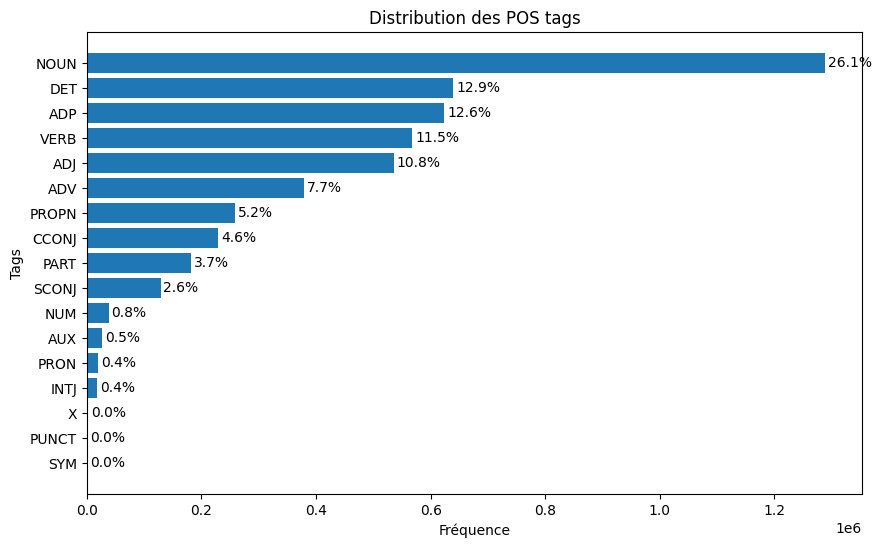

In [58]:
# Extraction des tags et fréquences, triés par ordre décroissant
tags, freqs = zip(*pos_counts.most_common())
total = sum(freqs)

plt.figure(figsize=(10, 6))
bars = plt.barh(tags, freqs)
plt.xlabel("Fréquence")
plt.ylabel("Tags")
plt.title("Distribution des POS tags")
plt.gca().invert_yaxis()  # Le tag le plus fréquent en haut

# Ajouter le pourcentage sur chaque barre
for bar in bars:
    width = bar.get_width()  # La largeur de la barre correspond à la fréquence
    percentage = width / total * 100
    # Placer le texte légèrement à droite de la fin de la barre
    plt.text(width + total * 0.001, bar.get_y() + bar.get_height()/2,
             f"{percentage:.1f}%", va='center', ha='left')

plt.show()

### <span style="color:green; font-size:1em; font-weight:bold;">  Lematization des données de test </span>

In [59]:
docs_test_texts = [" ".join(tokens) for tokens in docs_test]

# Utiliser nlp.pipe pour traiter les documents en lots
lemmatized_docs_test = [None] * len(docs_test_texts)
for i, doc in enumerate(nlp.pipe(docs_test_texts, batch_size=50, n_process=4)):
    lemmatized_docs_test[i] = [token.lemma_ for token in doc if token.pos_ not in {"SYM", "PRON", "X","PUNCT","AUX"}]
for i, (original, lemmatized) in enumerate(zip(docs_test_texts, lemmatized_docs_test)):
    print(f"Document {i+1}:")
    print("Original :", original)
    print("Lemmatized :", lemmatized)
    print()
    break

Document 1:
Original : i love sci fi and am willing to put up with a lot sci fi movies tv are usually underfunded under appreciated and misunderstood i tried to like this i really did but it is to good tv sci fi as babylon is to star trek the original silly prosthetics cheap cardboard sets stilted dialogues cg that does not match the background and painfully one dimensional characters cannot be overcome with a sci fi setting i m sure there are those of you out there who think babylon is good sci fi tv it s not it s clich d and uninspiring while us viewers might like emotion and character development sci fi is a genre that does not take itself seriously cf star trek it may treat important issues yet not as a serious philosophy it s really difficult to care about the characters here as they are not simply foolish just missing a spark of life their actions and reactions are wooden and predictable often painful to watch the makers of earth know it s rubbish as they have to always say gene 



### <span style="color:green; font-size:1em; font-weight:bold;">  Visualisation des lemmes les plus fréquents de chaque entité nommée : train </span>

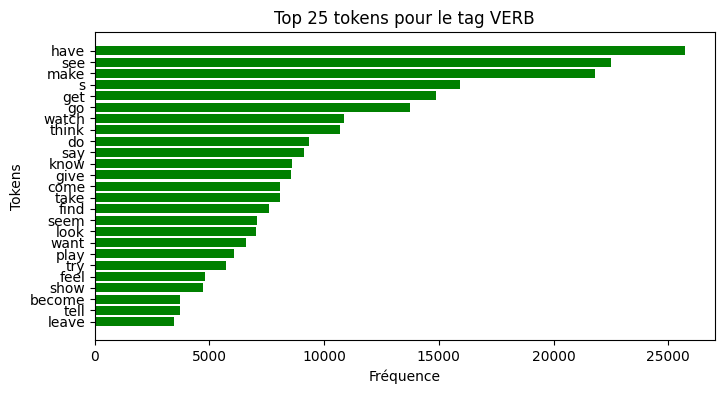

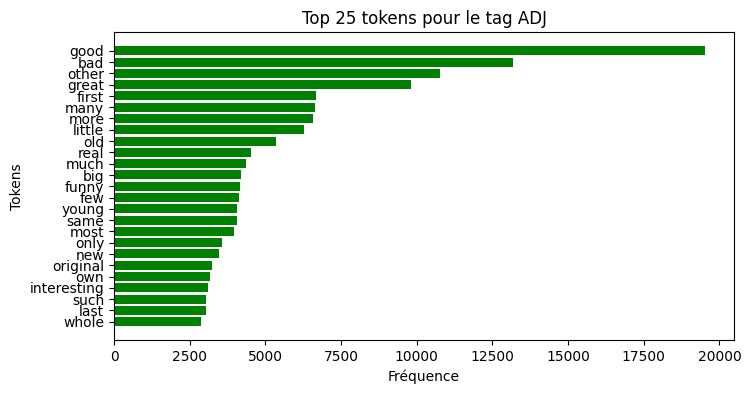

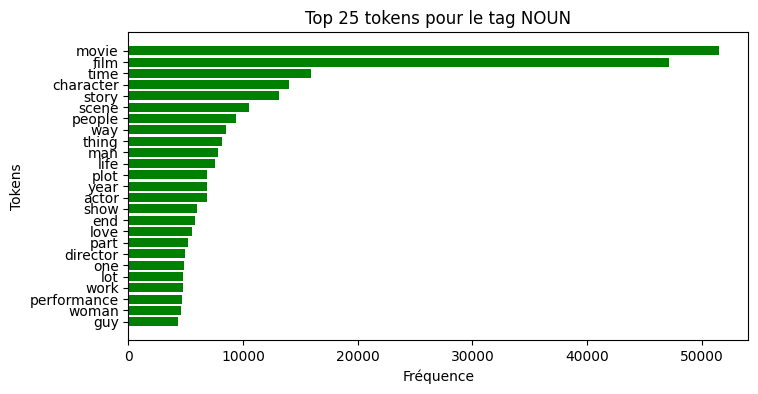

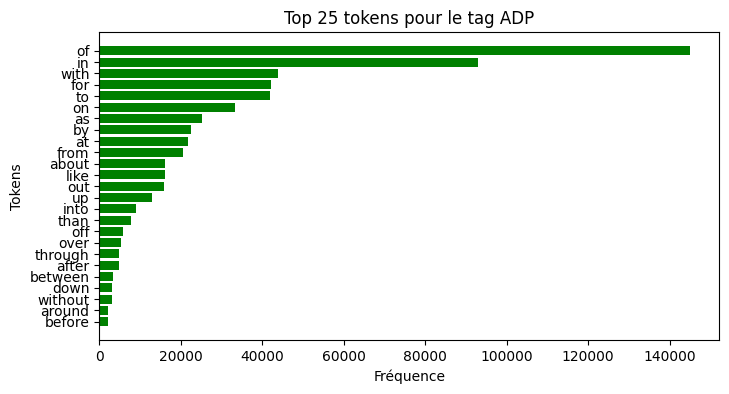

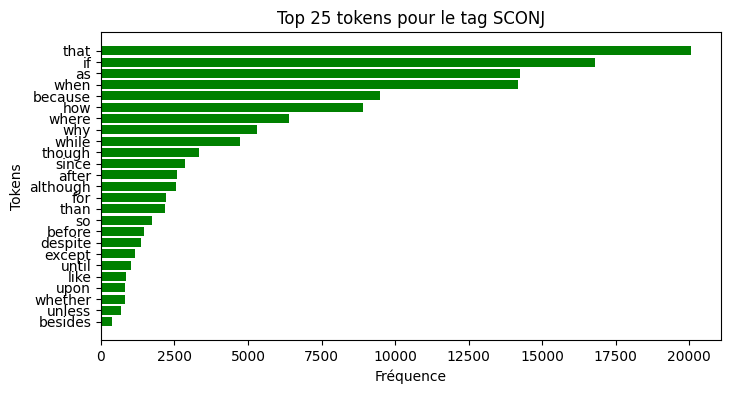

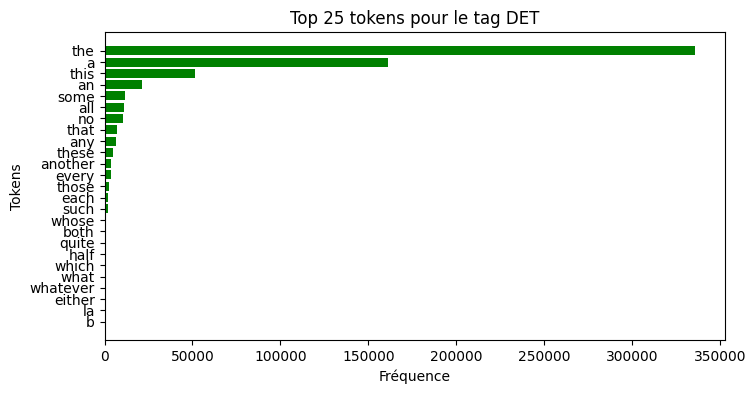

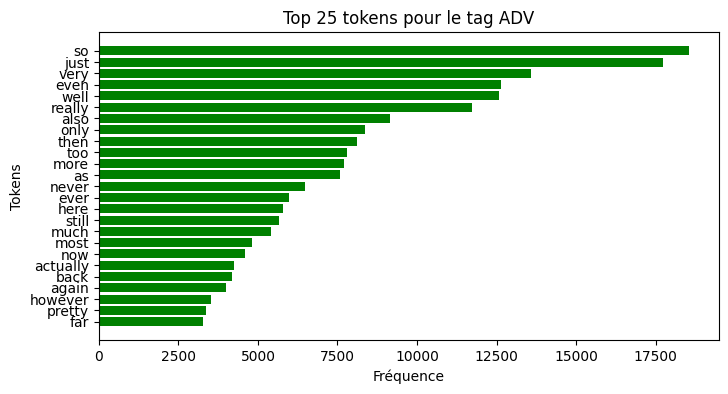

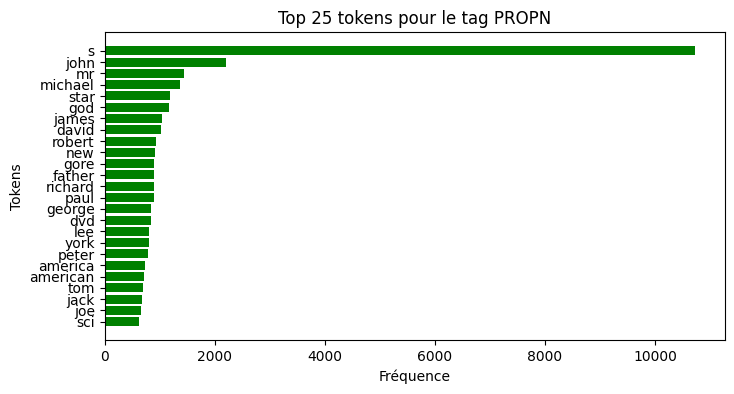

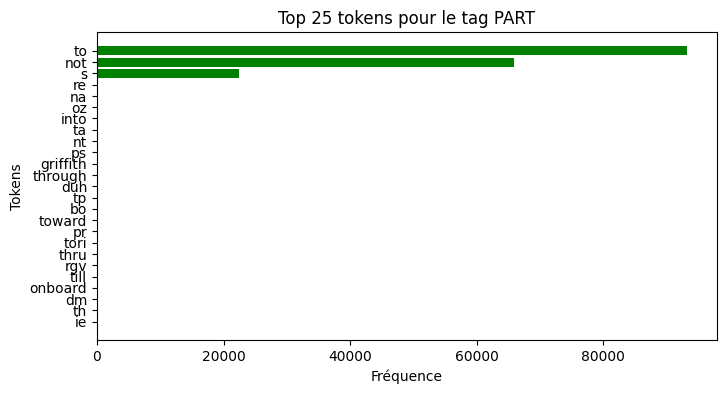

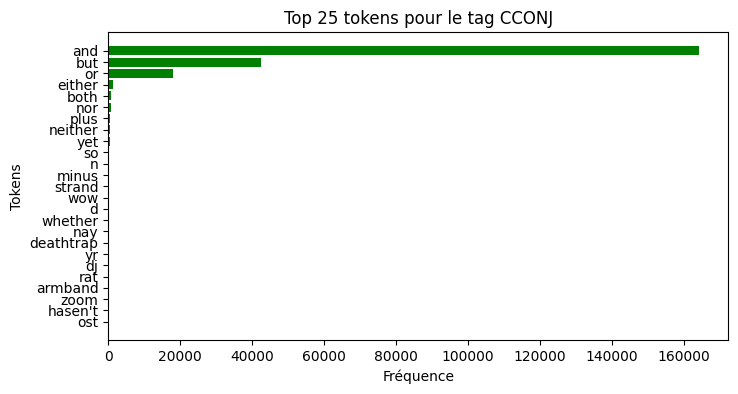

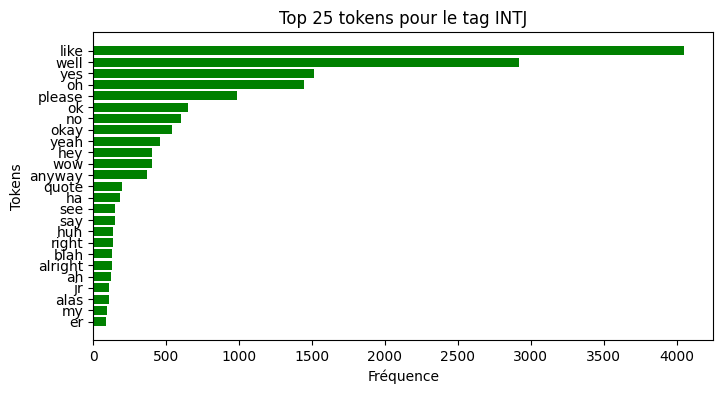

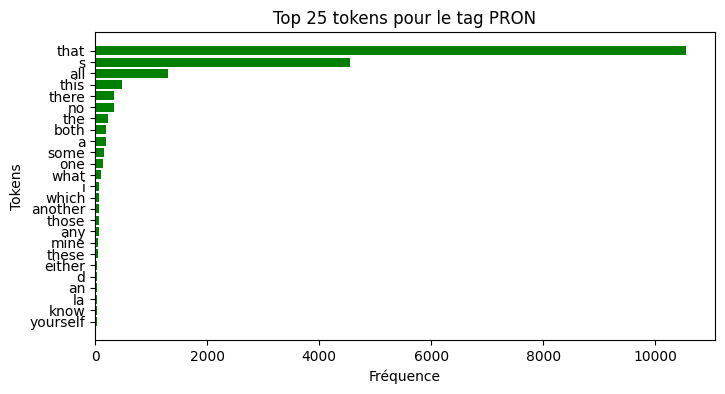

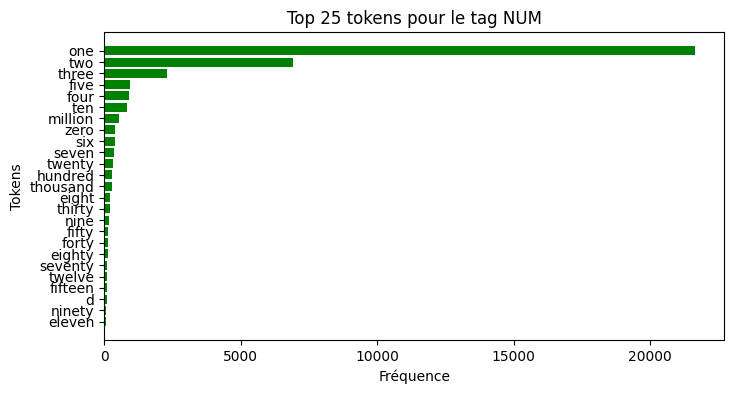

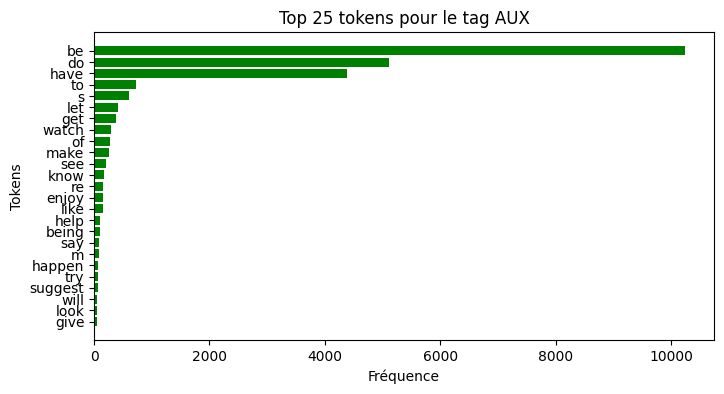

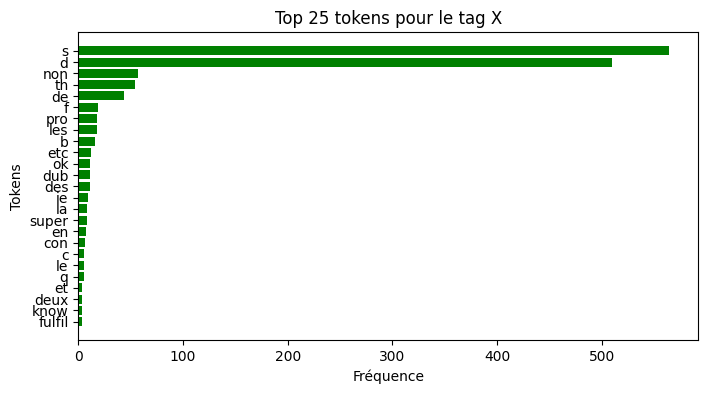

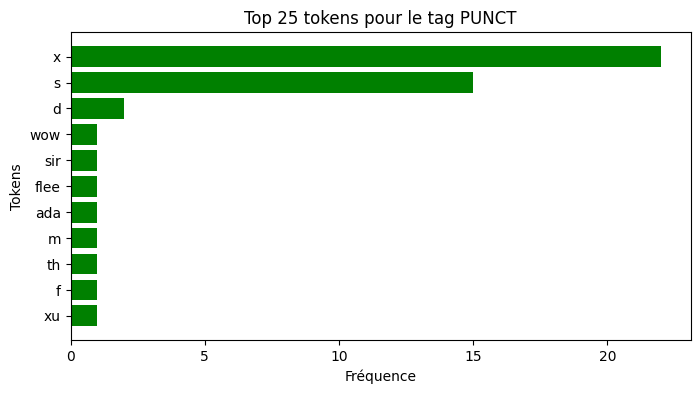

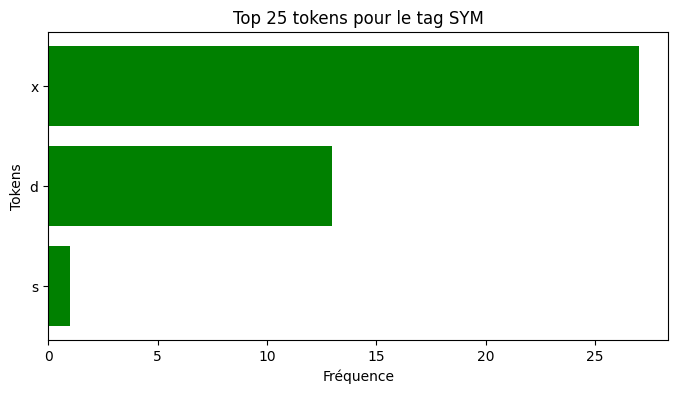

<Figure size 640x480 with 0 Axes>

In [60]:

# Récupérer la liste des tags (ici 17 tags)
tags = list(tokens_by_pos.keys())


# Tracer les 16 premiers tags dans les 4 premières lignes
for i in range(16):
    
    tag = tags[i]
    # On suppose que plot_top_tokens_for_tag accepte un paramètre ax
    plot_top_tokens_for_tag(tokens_by_pos, tag, top_n=25)
   
tag = tags[16]
plot_top_tokens_for_tag(tokens_by_pos, tag, top_n=25)

plt.tight_layout()
plt.show()


#### <span style="color:green; font-size:1em; font-weight:bold;"> Commentaire</span>
y mettre un commentaire succint des graphes précédetn

# <span style="color:green; font-size:1em; font-weight:bold;"> V- Analyse des sentiments</span>

Dans cette partie, l'analyse de sentiment proprement dite est faite.

-  Utilisation des mèthodes traditionnelles de machine learning telles que Naive Bayes, SVM, Random Forest et XGBoost. 

- Utilisation d'une méthode de Large Language Model, BERT.

<br>
Pour les méthodes de machine learning classique, il faut trouver une représentation des mots, token ou lemme. <br> 

-  Une première méthode qui consiste à utiliser les fréquences des mots appelée **tf-idf** est utilisée. Cette méthode ne prend pas en compte l'ordre des mots, la polysémie des mots.
<br>En plus, elle est sparse et peut augmenter la complexité de stockage et de calcul. <br>
- Une deuxième méthode **word2vec** qui est une méthode **embedding**. Contrairement à tf-idf, word2vec représente les mots sous forme de vecteurs de dimensions entre 50 et 1000, qui sont des vecteurs denses: les valeurs de ces vecteurs sont des réels qui peuvent être positifs ou négatifs.

In [61]:
X_train = train_neg_texts+train_pos_texts
X_test = test_neg_texts+test_pos_texts

## <span style="color:green; font-size:1em; font-weight:bold;"> TF-idf</span>

Cette représentation permet une représentation sous forme matricielle. <br>Chaque ligne représente un mot ou token ou lemme et chaque colonne représente un document. <br>La valeur de chaque cellule est la fréquence du mot pondérée par l'inverse de la fréquence du mot dans le corpus.<br> La représentation du mot est donnée par la formule suivante :

$$
\text{tf}_{t,d} = 
\begin{cases}
1 + \log_{10}(\text{count}(t,d)), & \text{si } \text{count}(t,d) > 0,\\
0, & \text{sinon}.
\end{cases}
$$
où $\text{count}(t,d)$ est le nombre d'occurrences du mot $t$ dans le document $d$ et $log_{10}$ est le logarithme en base 10.

L’idée est que compter un mot (disons, 100 fois) dans un document ne rend pas ce mot proportionnellement plus important pour caractériser le sens du document.<br> En d’autres termes, si un mot apparaît énormément, ce n’est pas forcément parce qu’il est sémantiquement central à la thématique. C’est plutôt que ce mot peut être très commun ou contextuel. <br> C’est pourquoi on utilise une pondération comme la fonction logarithmique pour réduire l’impact des mots apparaissant très fréquemment et ne pas leur donner un poids démesuré dans la représentation du document.
<br> <br>
Dans la cellule  suivante, nous utilisons les pipelines pour entrainer les modèles de machine learning. L'entrainement se fait en trois étapes :

- Transformation des mots token ou lemme en supprimant les tags `SYM`, `PUNCT`, `X`, `AUX`, et `PRON`.
- Transformation des mots en vecteurs en utilisant la méthode tf-idf.
- Entrainement des modèles de machine learning (Naive Bayes, Régression logistique, Régression logistique avec régularisation, SVM, XGBoost).

In [67]:
exec(open(os.path.join(current_dir, "functions.py")).read())

/tmp/ipykernel_20173/830775120.py:1: ResourceWarning: unclosed file <_io.TextIOWrapper name='/home/onyxia/work/functions.py' mode='r' encoding='UTF-8'>
  exec(open(os.path.join(current_dir, "functions.py")).read())


In [68]:
# Définition des  pipelines pour chaque modèle utilisé
pipeline_with_nb = Pipeline([
    ('lemmatizer', Lemmatizer(batch_size=100, n_process=1, excluded_tags={"SYM", "PRON", "X", "PUNCT", "AUX"})),
    ('tfidf', TfidfVectorizer()),
    ('clf', MultinomialNB())
])

pipeline_with_lr = Pipeline([
    ('lemmatizer', Lemmatizer(batch_size=100, n_process=1, excluded_tags={"SYM", "PRON", "X", "PUNCT", "AUX"})),
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(max_iter=500))  # Increased max_iter for convergence
])

pipeline_with_svm = Pipeline([
    ('lemmatizer', Lemmatizer(batch_size=100, n_process=1, excluded_tags={"SYM", "PRON", "X", "PUNCT", "AUX"})),
    ('tfidf', TfidfVectorizer()),
    ('clf', SVC())
])

pipeline_with_xgb = Pipeline([
    ('lemmatizer', Lemmatizer(batch_size=100, n_process=1, excluded_tags={"SYM", "PRON", "X", "PUNCT", "AUX"})),
    ('tfidf', TfidfVectorizer()),
    ('clf', XGBClassifier(
        objective='binary:logistic',
        seed=12345,
        gamma=0,
        learning_rate=0.05,
        max_depth=5,
        n_estimators=200,
        eval_metric='logloss'
    ))
])

pipeline_with_elasticnet = Pipeline([
    ('lemmatizer', Lemmatizer(batch_size=100, n_process=1, excluded_tags={"SYM", "PRON", "X", "PUNCT", "AUX"})),
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegressionCV(
        penalty='elasticnet',
        l1_ratios=[0.1, 0.5, 0.9],  #les ratios
        cv=5,
        solver='saga',
        tol=0.01,
        random_state=12345,
        max_iter=1000  # pour la convergence
    ))
])

#  parameter grids pour chaque modele
param_grids = {
    'nb': {
        'tfidf__max_df': [0.8, 1.0],
        'clf__alpha': [0.1, 1.0]
    },
    'lr': {
        'tfidf__max_df': [0.8, 1.0],
        'clf__C': [0.01, 0.1],
        'clf__penalty': ['l2']
    },
    'svm': {
        'tfidf__max_df': [0.8, 1.0],
        'clf__C': [0.1,  10.0],
        'clf__kernel': ['linear', 'rbf']
    },
    'xgb': {
        'tfidf__max_df': [0.8, 1.0],
        'clf__learning_rate': [0.01, 0.05],
        'clf__max_depth': [3,  7],
        'clf__n_estimators': [100, 200]
    },
    'elasticnet': {
        'tfidf__max_df': [0.8, 1.0],
        'clf__Cs': [1, 5]  #  inverse regularization 
    }
}

# dictionnaire de pipeline
pipelines = {
    'nb': pipeline_with_nb,
    'lr': pipeline_with_lr,
    'svm': pipeline_with_svm,
    'xgb': pipeline_with_xgb,
    'elasticnet': pipeline_with_elasticnet
}

# Construire GridSearchCV pour chaque modèle

grid_searches = {}
for name, pipeline in pipelines.items():
    grid_searches[name] = GridSearchCV(
        pipeline,
        param_grid=param_grids[name],
        cv=3,
        verbose=2,
        n_jobs=1,  # SMETTRE A 1 POUR EVITER LES CONFLICTS AVEC SPACY
        error_score='raise'  # Raise errors for better debugging
    )

# LISTE des noms de modèles
model_names = ['nb', 'lr', 'svm', 'xgb', 'elasticnet']

# Dictionaires pour sauvegarder les predictions
y_preds_train = {}

# Entraîner chaque modèle avec GridSearchCV
for name in model_names:
    print(f"Entraînement du modèle : {name.upper()} ...")
    with suppress_warnings():
        with parallel_backend('threading'):  # Backend threading pour éviter les conflits
            grid_searches[name].fit(X_train, y_train)
    print(f"Meilleurs paramètres pour {name.upper()} : {grid_searches[name].best_params_}")
    
    # Prédire sur les données d'entraînement
    with suppress_warnings():
        y_preds_train[name] = grid_searches[name].predict(X_train)

Entraînement du modèle : NB ...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END ..................clf__alpha=0.1, tfidf__max_df=0.8; total time= 5.4min
[CV] END ..................clf__alpha=0.1, tfidf__max_df=0.8; total time= 5.3min
[CV] END ..................clf__alpha=0.1, tfidf__max_df=0.8; total time= 5.2min
[CV] END ..................clf__alpha=0.1, tfidf__max_df=1.0; total time= 5.0min
[CV] END ..................clf__alpha=0.1, tfidf__max_df=1.0; total time= 5.2min
[CV] END ..................clf__alpha=0.1, tfidf__max_df=1.0; total time= 4.8min
[CV] END ..................clf__alpha=1.0, tfidf__max_df=0.8; total time= 5.0min
[CV] END ..................clf__alpha=1.0, tfidf__max_df=0.8; total time= 5.0min
[CV] END ..................clf__alpha=1.0, tfidf__max_df=0.8; total time= 5.0min
[CV] END ..................clf__alpha=1.0, tfidf__max_df=1.0; total time= 5.1min
[CV] END ..................clf__alpha=1.0, tfidf__max_df=1.0; total time= 4.7min
[CV] END ........

InvalidParameterError: The 'Cs' parameter of LogisticRegressionCV must be an int in the range [1, inf) or an array-like. Got 0.01 instead.

In [77]:
#REPRENDRE elasticnet car on a fait une erreur dans le precedent

param_grids = {
    'nb': {
        'tfidf__max_df': [0.8, 1.0],
        'clf__alpha': [0.1, 1.0]
    },
    'lr': {
        'tfidf__max_df': [0.8, 1.0],
        'clf__C': [0.01, 0.1],
        'clf__penalty': ['l2']
    },
    'svm': {
        'tfidf__max_df': [0.8, 1.0],
        'clf__C': [0.1,  10.0],
        'clf__kernel': ['linear', 'rbf']
    },
    'xgb': {
        'tfidf__max_df': [0.8, 1.0],
        'clf__learning_rate': [0.01, 0.05],
        'clf__max_depth': [3,  7],
        'clf__n_estimators': [100, 200]
    },
    'elasticnet': {
        'tfidf__max_df': [0.8, 1.0, 2]
        #'clf__Cs': [1, 5]  #  inverse regularization 
    }
}

grid_searches['elasticnet'] = GridSearchCV(
        pipeline,
        param_grid=param_grids['elasticnet'],
        cv=3,
        verbose=2,
        n_jobs=1,  # SMETTRE A 1 POUR EVITER LES CONFLICTS AVEC SPACY
        error_score='raise'  # Raise errors for better debugging
    )

with suppress_warnings():
    with parallel_backend('threading'):  # Backend threading pour éviter les conflits
        grid_searches['elasticnet'].fit(X_train, y_train)
        print(f"Meilleurs paramètres pour {'elasticnet'.upper()} : {grid_searches['elasticnet'].best_params_}")
    
# Prédire sur les données d'entraînement
with suppress_warnings():
    y_preds_train['elasticnet'] = grid_searches['elasticnet'].predict(X_train)


Fitting 3 folds for each of 3 candidates, totalling 9 fits
[CV] END ..................................tfidf__max_df=0.8; total time= 5.8min
[CV] END ..................................tfidf__max_df=0.8; total time= 6.0min
[CV] END ..................................tfidf__max_df=0.8; total time= 6.2min
[CV] END ..................................tfidf__max_df=1.0; total time= 5.9min
[CV] END ..................................tfidf__max_df=1.0; total time= 6.1min
[CV] END ..................................tfidf__max_df=1.0; total time= 5.8min
[CV] END ....................................tfidf__max_df=2; total time= 6.7min
[CV] END ....................................tfidf__max_df=2; total time= 6.4min
[CV] END ....................................tfidf__max_df=2; total time= 6.7min
Meilleurs paramètres pour ELASTICNET : {'tfidf__max_df': 0.8}


In [78]:
# Dictionnaire pour stocker les prédictions sur les données de test
y_preds_test = {}

# Prédire sur les données de test
for name in model_names:
    print(f"Prédiction sur les données de test avec : {name.upper()}")
    with suppress_warnings():
        y_preds_test[name] = grid_searches[name].predict(X_test)


Prédiction sur les données de test avec : NB
Prédiction sur les données de test avec : LR
Prédiction sur les données de test avec : SVM
Prédiction sur les données de test avec : XGB
Prédiction sur les données de test avec : ELASTICNET


### <span style="color:green; font-size:0.8em; font-weight:bold;"> Evaluation des performances des modèles</span>

La fonction `evaluate_model` permet d'évaluer les performances des modèles en utilisant les métriques suivantes : précision, rappel, F1-score.

In [79]:
print("====================================================")
print("***************************************************")
print("    Évaluation sur le jeu d'entraînement           ")
print("***************************************************")
print("====================================================")

for name in model_names:
    print(f"--- {name.upper()} ---")
    evaluate_model(name.upper(), y_train, y_preds_train[name])

print("====================================================")
print("***************************************************")
print("    Évaluation sur les données de test             ")
print("***************************************************")
print("====================================================")

for name in model_names:
    print(f"--- {name.upper()} ---")
    evaluate_model(name.upper(), y_test, y_preds_test[name])


***************************************************
    Évaluation sur le jeu d'entraînement           
***************************************************
--- NB ---

--- NB ---
Accuracy : 0.9058
Precision: 0.922110343679787
Recall   : 0.88648
F1-score : 0.903944201982298
--- LR ---

--- LR ---
Accuracy : 0.87364
Precision: 0.855414352028004
Recall   : 0.89928
F1-score : 0.8767988767988768
--- SVM ---

--- SVM ---
Accuracy : 0.89616
Precision: 0.8784775298073983
Recall   : 0.91952
F1-score : 0.8985303314571608
--- XGB ---

--- XGB ---
Accuracy : 0.91284
Precision: 0.8884456153556642
Recall   : 0.94424
F1-score : 0.9154935039751794
--- ELASTICNET ---

--- ELASTICNET ---
Accuracy : 0.94112
Precision: 0.9364413487414912
Recall   : 0.94648
F1-score : 0.941433914219782
***************************************************
    Évaluation sur les données de test             
***************************************************
--- NB ---

--- NB ---
Accuracy : 0.82472
Precision: 0.8678629690048

#### <span style="color:green; font-size:1em; font-weight:bold;"> Commentaire</span>
Les résultats des modèles avec TF-IDF montrent qu'ElasticNet domine avec une précision de 0,9411 sur l'ensemble d'entraînement et 0,8784 sur le test, suivi de près par SVM (0,8962 et 0,8684). <br><br> Ces modèles linéaires excellent grâce à leur robustesse aux représentations sparse, offrant un bon équilibre entre précision et rappel. <br><br>Naive Bayes et XGBoost, bien que performants sur l'entraînement (0,9058 et 0,9128), souffrent d'un surajustement marqué, avec des précisions test de 0,8247 et 0,8358, respectivement.


### <span style="color:green; font-size:0.8em; font-weight:bold;"> Courbe de ROC et AUC</span>

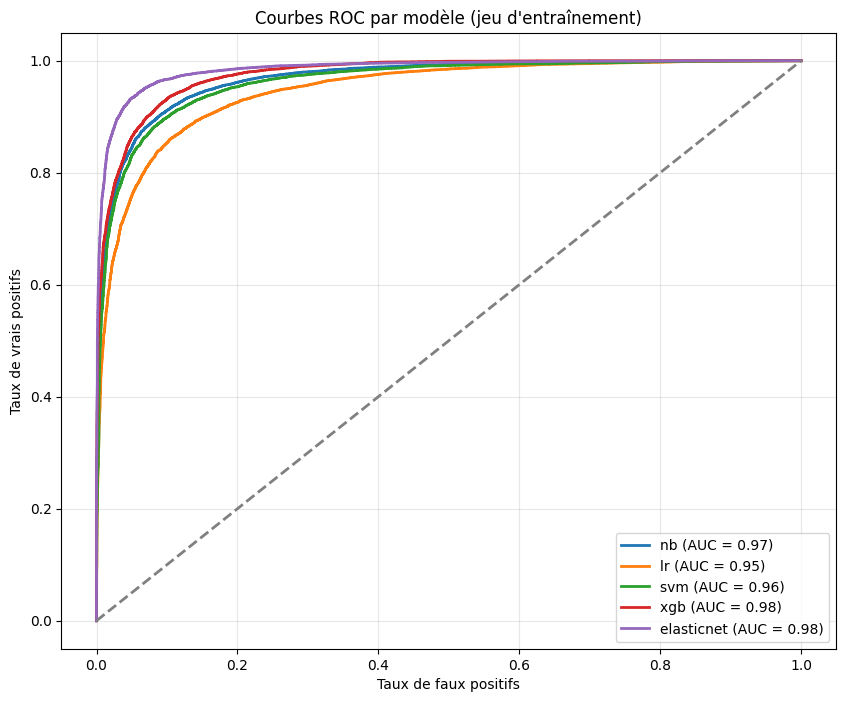

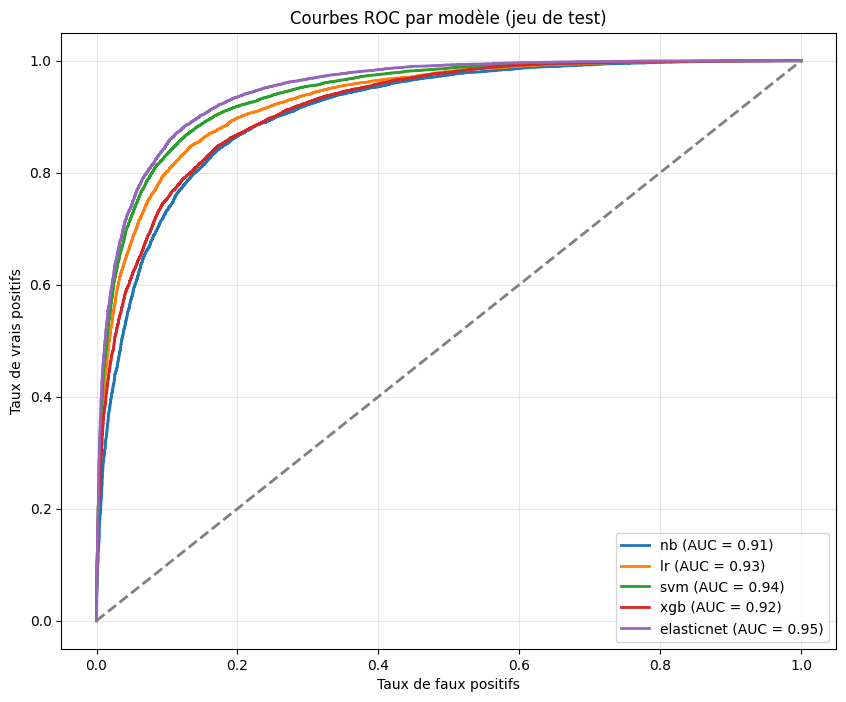

In [80]:

# Générer les ROC à partir des modèles entraînés
with suppress_warnings():
    roc_results_train = compute_roc(grid_searches, X_train, y_train)
    roc_results_test = compute_roc(grid_searches, X_test, y_test)

# Courbes ROC - Entraînement
plt.figure(figsize=(10, 8))
for name, roc in roc_results_train.items():
    plt.plot(roc['fpr'], roc['tpr'], lw=2, label=f'{name} (AUC = {roc["roc_auc"]:.2f})')
plt.plot([0, 1], [0, 1], '--', color='gray', lw=2)
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbes ROC par modèle (jeu d\'entraînement)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Courbes ROC - Test
plt.figure(figsize=(10, 8))
for name, roc in roc_results_test.items():
    plt.plot(roc['fpr'], roc['tpr'], lw=2, label=f'{name} (AUC = {roc["roc_auc"]:.2f})')
plt.plot([0, 1], [0, 1], '--', color='gray', lw=2)
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbes ROC par modèle (jeu de test)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


#### <span style="color:green; font-size:1em; font-weight:bold;"> Commentaire</span>
Sur l'ensemble d'entraînement, toutes les courbes ROC montrent des AUC élevées (proches de 1), avec ElasticNet (AUC = 0.98) et XGBoost (AUC = 0.98) dominant, suivis de SVM (AUC = 0.96) et Régression Logistique (AUC = 0.95), ET  Naive Bayes (AUC = 0.97). <br> <br> ElasticNet et XGBoost capturant efficacement les patterns. <br> <br> Sur l'ensemble de test, les AUC diminuent, indiquant un léger surajustement : ElasticNet conserve la meilleure performance (AUC = 0.95), suivi de SVM (AUC = 0.94), Régression Logistique (AUC = 0.93), XGBoost (AUC = 0.92), et Naive Bayes (AUC = 0.91).<br> <br> La baisse est notable pour XGBoost et Naive Bayes, confirmant une généralisation moins robuste, tandis qu'ElasticNet et SVM maintiennent une bonne capacité discriminative. <br> <br>Ces résultats corroborent les métriques précédentes, soulignant la robustesse d'ElasticNet et SVM avec TF-IDF.

## <span style="color:green; font-size:1em; font-weight:bold;"> Word2Vec</span>

Les embeddings **Word2vec** sont des **embeddings statiques**, ce qui signifie que la méthode apprend **une représentation (embedding) fixe pour chaque mot** dans le vocabulaire d’embeddings statiques.<br> 
Il utilise l'algorithme Skip-gram pour apprendre les embeddings :

-  Considérer le mot cible et un mot de contexte voisin comme des exemples positifs.  
-  Échantillonner aléatoirement d’autres mots dans le lexique pour obtenir des échantillons négatifs.  
-  Utiliser la régression logistique pour entraîner un classifieur à distinguer ces deux cas.  
-  Utiliser les poids appris comme embeddings.



In [81]:
exec(open(os.path.join(current_dir, "functions.py")).read())

/tmp/ipykernel_20173/830775120.py:1: ResourceWarning: unclosed file <_io.TextIOWrapper name='/home/onyxia/work/functions.py' mode='r' encoding='UTF-8'>
  exec(open(os.path.join(current_dir, "functions.py")).read())


In [83]:
# Définir les pipelines avec Word2Vec
pipeline_with_nb = Pipeline([
    ('lemmatizer', Lemmatizer(batch_size=200, n_process=1, excluded_tags={"SYM", "PRON", "X", "PUNCT", "AUX"})),
    ('word2vec', Word2VecVectorizer(vector_size=100, window=5, min_count=5, workers=1)),
    ('clf', GaussianNB())
])

pipeline_with_lr = Pipeline([
    ('lemmatizer', Lemmatizer(batch_size=200, n_process=1, excluded_tags={"SYM", "PRON", "X", "PUNCT", "AUX"})),
    ('word2vec', Word2VecVectorizer(vector_size=100, window=5, min_count=5, workers=1)),
    ('clf', LogisticRegression(max_iter=500))
])

pipeline_with_svm = Pipeline([
    ('lemmatizer', Lemmatizer(batch_size=200, n_process=1, excluded_tags={"SYM", "PRON", "X", "PUNCT", "AUX"})),
    ('word2vec', Word2VecVectorizer(vector_size=100, window=5, min_count=5, workers=1)),
    ('clf', SVC())
])

pipeline_with_xgb = Pipeline([
    ('lemmatizer', Lemmatizer(batch_size=200, n_process=1, excluded_tags={"SYM", "PRON", "X", "PUNCT", "AUX"})),
    ('word2vec', Word2VecVectorizer(vector_size=100, window=5, min_count=5, workers=1)),
    ('clf', XGBClassifier(
        objective='binary:logistic',
        seed=12345,
        gamma=0,
        learning_rate=0.05,
        max_depth=5,
        n_estimators=100,
        eval_metric='logloss'
    ))
])

pipeline_with_elasticnet = Pipeline([
    ('lemmatizer', Lemmatizer(batch_size=200, n_process=1, excluded_tags={"SYM", "PRON", "X", "PUNCT", "AUX"})),
    ('word2vec', Word2VecVectorizer(vector_size=100, window=5, min_count=5, workers=1)),
    ('clf', LogisticRegressionCV(
        penalty='elasticnet',
        l1_ratios=[0.5],
        cv=3,
        solver='saga',
        tol=0.01,
        random_state=12345,
        max_iter=300
    ))
])

# Définir des grilles d'hyperparamètres réduites
param_grids = {
    'nb': {
        'word2vec__vector_size': [100, 200],
        'word2vec__window': [5, 10],
        'clf__var_smoothing': [1e-9, 1e-6]
    },
    'lr': {
        'word2vec__vector_size': [100, 200],
        'word2vec__window': [5, 10],
        'clf__C': [1.0]
    },
    'svm': {
        'word2vec__vector_size': [100, 200],
        'word2vec__window': [5, 10],
        'clf__C': [1.0],
        'clf__kernel': ['rbf']
    },
    'xgb': {
        'word2vec__vector_size': [100, 200],
        'word2vec__window': [5, 10],
        'clf__learning_rate': [0.05, 0.1],
        'clf__max_depth': [5],
        'clf__n_estimators': [100]
    },
    'elasticnet': {
        'word2vec__vector_size': [100, 200],
        'word2vec__window': [5, 10]
    }
}

# Dictionnaire des pipelines
pipelines = {
    'nb': pipeline_with_nb,
    'lr': pipeline_with_lr,
    'svm': pipeline_with_svm,
    'xgb': pipeline_with_xgb,
    'elasticnet': pipeline_with_elasticnet
}

# Construire GridSearchCV pour chaque modèle
grid_searches2 = {}
import multiprocessing
num_cores = multiprocessing.cpu_count()
n_jobs = max(1, num_cores - 1)  # Utiliser tous les cœurs sauf un
for name, pipeline in pipelines.items():
    grid_searches2[name] = GridSearchCV(
        pipeline,
        param_grid=param_grids[name],
        cv=3,
        verbose=2,
        n_jobs=1,  # Nombre de cœurs limité
        error_score='raise'
    )

# Liste des noms de modèles
model_names = ['nb', 'lr', 'svm', 'xgb', 'elasticnet']

# Dictionnaire pour stocker les prédictions
y_preds_train2 = {}

# Entraîner chaque modèle avec GridSearchCV
for name in model_names:
    print(f"Entraînement du modèle : {name.upper()} ...")
    with suppress_warnings():
        with parallel_backend('threading'):  # Backend threading pour éviter les conflits
            grid_searches2[name].fit(X_train, y_train)
    print(f"Meilleurs paramètres pour {name.upper()} : {grid_searches2[name].best_params_}")
    
    # Prédire sur les données d'entraînement
    with suppress_warnings():
        y_preds_train2[name] = grid_searches2[name].predict(X_train)

Entraînement du modèle : NB ...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END clf__var_smoothing=1e-09, word2vec__vector_size=100, word2vec__window=5; total time= 5.0min
[CV] END clf__var_smoothing=1e-09, word2vec__vector_size=100, word2vec__window=5; total time= 5.1min
[CV] END clf__var_smoothing=1e-09, word2vec__vector_size=100, word2vec__window=5; total time= 5.3min
[CV] END clf__var_smoothing=1e-09, word2vec__vector_size=100, word2vec__window=10; total time= 5.1min
[CV] END clf__var_smoothing=1e-09, word2vec__vector_size=100, word2vec__window=10; total time= 5.0min
[CV] END clf__var_smoothing=1e-09, word2vec__vector_size=100, word2vec__window=10; total time= 5.1min
[CV] END clf__var_smoothing=1e-09, word2vec__vector_size=200, word2vec__window=5; total time= 5.1min
[CV] END clf__var_smoothing=1e-09, word2vec__vector_size=200, word2vec__window=5; total time= 4.9min
[CV] END clf__var_smoothing=1e-09, word2vec__vector_size=200, word2vec__window=5; total time= 4.9

In [84]:
# Dictionnaire pour stocker les prédictions sur les données de test
y_preds_test2 = {}

# Prédire sur les données de test
for name in model_names:
    print(f"Prédiction sur les données de test avec : {name.upper()}")
    with suppress_warnings():
        y_preds_test2[name] = grid_searches2[name].predict(X_test)

Prédiction sur les données de test avec : NB
Prédiction sur les données de test avec : LR
Prédiction sur les données de test avec : SVM
Prédiction sur les données de test avec : XGB
Prédiction sur les données de test avec : ELASTICNET


### <span style="color:green; font-size:0.8em; font-weight:bold;"> Evaluation des performances des modèles</span>

In [85]:
print("====================================================")
print("***************************************************")
print("    Évaluation sur le jeu d'entraînement           ")
print("***************************************************")
print("====================================================")

for name in model_names:
    evaluate_model(name.upper(), y_train, y_preds_train2[name])

print("====================================================")
print("***************************************************")
print("    Évaluation sur les données de test             ")
print("***************************************************")
print("====================================================")

for name in model_names:
    evaluate_model(name.upper(), y_test, y_preds_test2[name])


***************************************************
    Évaluation sur le jeu d'entraînement           
***************************************************

--- NB ---
Accuracy : 0.71044
Precision: 0.7155617471113661
Recall   : 0.69856
F1-score : 0.7069586689875723

--- LR ---
Accuracy : 0.83036
Precision: 0.8266751048176568
Recall   : 0.836
F1-score : 0.8313114036832266

--- SVM ---
Accuracy : 0.8402
Precision: 0.8335555729861166
Recall   : 0.85016
F1-score : 0.8417759119173036

--- XGB ---
Accuracy : 0.88524
Precision: 0.8790240062967336
Recall   : 0.89344
F1-score : 0.8861733782979567

--- ELASTICNET ---
Accuracy : 0.83084
Precision: 0.826839484707184
Recall   : 0.83696
F1-score : 0.8318689619528485
***************************************************
    Évaluation sur les données de test             
***************************************************

--- NB ---
Accuracy : 0.70348
Precision: 0.7164128307666128
Recall   : 0.6736
F1-score : 0.6943470910815157

--- LR ---
Accuracy : 

#### <span style="color:green; font-size:1em; font-weight:bold;"> Commentaire</span>

commenter les résultats précédents

### <span style="color:green; font-size:0.8em; font-weight:bold;"> Courbe de ROC et AUC</span>


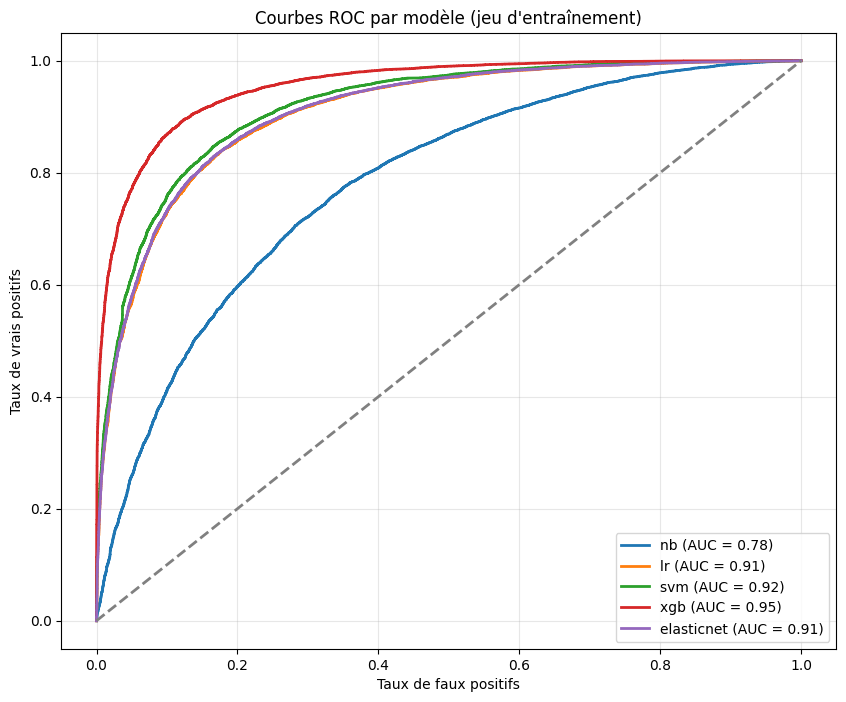

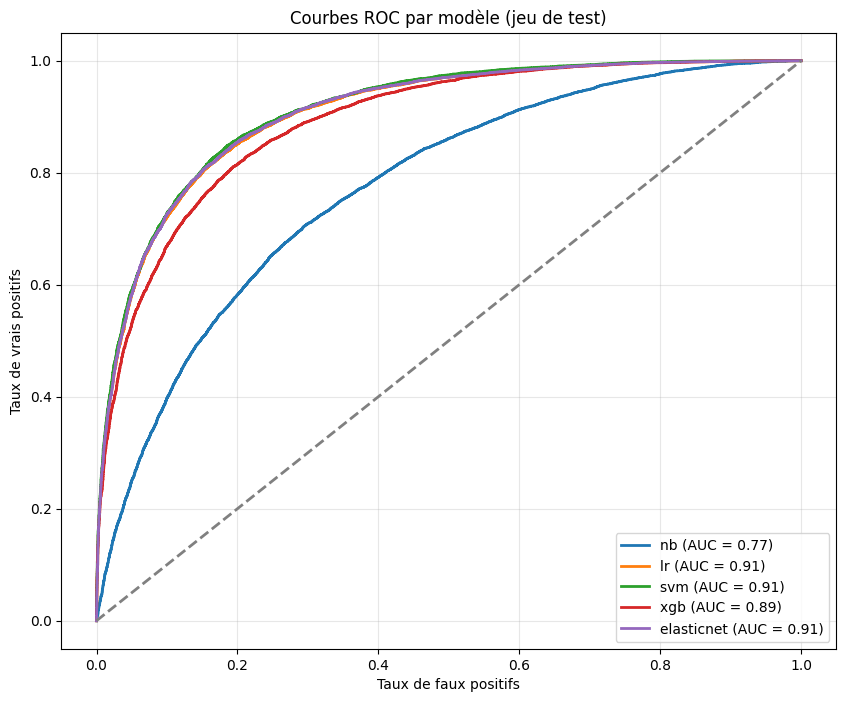

In [86]:

# Générer les ROC à partir des modèles entraînés
with suppress_warnings():
    roc_results_train2 = compute_roc(grid_searches2, X_train, y_train)
    roc_results_test2 = compute_roc(grid_searches2, X_test, y_test)

# Courbes ROC - Entraînement
plt.figure(figsize=(10, 8))
for name, roc in roc_results_train2.items():
    plt.plot(roc['fpr'], roc['tpr'], lw=2, label=f'{name} (AUC = {roc["roc_auc"]:.2f})')
plt.plot([0, 1], [0, 1], '--', color='gray', lw=2)
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbes ROC par modèle (jeu d\'entraînement)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Courbes ROC - Test
plt.figure(figsize=(10, 8))
for name, roc in roc_results_test2.items():
    plt.plot(roc['fpr'], roc['tpr'], lw=2, label=f'{name} (AUC = {roc["roc_auc"]:.2f})')
plt.plot([0, 1], [0, 1], '--', color='gray', lw=2)
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbes ROC par modèle (jeu de test)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


#### <span style="color:green; font-size:1em; font-weight:bold;"> Commentaire</span>

Les courbes ROC des modèles avec Word2Vec montrent des performances stables entre les ensembles d’entraînement et de test. 

Sur l’ensemble d’entraînement, XGBoost atteint le meilleur AUC (0,95), suivi de SVM (0,92), Régression Logistique et ElasticNet (0,91 chacun), tandis que Naive Bayes est en retrait avec 0,78, reflétant une capacité discriminative limitée due à son hypothèse d’indépendance inadaptée aux embeddings denses. 

Sur l’ensemble de test, les AUC restent proches : SVM, Régression Logistique et ElasticNet maintiennent un solide 0,91, XGBoost baisse légèrement à 0,89, et Naive Bayes reste à 0,77. 

Cette stabilité certifie une généralisation correcte pour les modèles linéaires (SVM, ElasticNet), bien que leurs AUC soient inférieures à celles de TF-IDF (0,95 pour ElasticNet). 

Naive Bayes sous-performe constamment, tandis que la baisse modérée de XGBoost (0,95 à 0,89) met en lumière un léger surajustement.

## <span style="color:green; font-size:1em; font-weight:bold;"> Large Language Model : BERT</span>


C’est un modèle de transformeur bidirectionnel pré-entraîné. Son entraînement repose sur le **masked language modeling** : au lieu de prédire le mot suivant, on masque un mot au milieu de la phrase et on demande au modèle de le deviner en se basant à la fois sur les mots à gauche et à droite. Ainsi, le modèle peut tenir compte du contexte de chaque côté.

La puissance des modèles de langage pré-entraînés réside dans leur capacité à extraire des généralisations à partir de grandes quantités de texte – des généralisations utiles pour toute une variété d’applications ultérieures.

Il peut être utilisé pour les classifications séquentielles qui consiste à classifier une séquence de mots en une seule catégorie. Donc peut être utilisé pour la classification de sentiment.

In [87]:
# Tokeniser et encoder les données avec BERT
try:
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=True)
    max_len = 128
    X_train_encoded = tokenizer.batch_encode_plus(
        X_train,
        padding=True,
        truncation=True,
        max_length=max_len,
        return_tensors='pt'
    )
    X_test_encoded = tokenizer.batch_encode_plus(
        X_test,
        padding=True,
        truncation=True,
        max_length=max_len,
        return_tensors='pt'
    )
    print("encodage des données avec BERT réussi")
except Exception as e:
    print(f"Erreur lors de l'encodage BERT: {str(e)}")
    raise

encodage des données avec BERT réussi


In [88]:
# Création des datasets PyTorch
train_dataset = TensorDataset(
    X_train_encoded['input_ids'],
    X_train_encoded['attention_mask'],
    torch.tensor(y_train, dtype=torch.long)
)
test_dataset = TensorDataset(
    X_test_encoded['input_ids'],
    X_test_encoded['attention_mask'],
    torch.tensor(y_test, dtype=torch.long)
)

# Créer des DataLoaders
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [89]:
# Inspection d’un échantillon encodé pour l'entraînement BERT
k = 0
print('Training Comments -->>',X_train[k])
print('\nInput Ids -->>\n',X_train_encoded['input_ids'][k])
print('\nDecoded Ids -->>\n',tokenizer.decode(X_train_encoded['input_ids'][k]))
print('\nAttention Mask -->>\n',X_train_encoded['attention_mask'][k])
print('\nLabels -->>',y_train[k])

Training Comments -->> i rented i am curious yellow from my video store because of all the controversy that surrounded it when it was first released in i also heard that at first it was seized by u s customs if it ever tried to enter this country therefore being a fan of films considered controversial i really had to see this for myself the plot is centered around a young swedish drama student named lena who wants to learn everything she can about life in particular she wants to focus her attentions to making some sort of documentary on what the average swede thought about certain political issues such as the vietnam war and race issues in the united states in between asking politicians and ordinary denizens of stockholm about their opinions on politics she has sex with her drama teacher classmates and married men what kills me about i am curious yellow is that years ago this was considered pornographic really the sex and nudity scenes are few and far between even then it s not shot li

In [90]:

# Charger le modèle BERT
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
model.to(device)

# Définir l'optimiseur
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

# Entraîner le modèle BERT
num_epochs = 3
model.train()
for epoch in range(num_epochs):
    total_loss = 0
    for batch in train_loader:
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/len(train_loader):.4f}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3, Loss: 0.3179
Epoch 2/3, Loss: 0.1862
Epoch 3/3, Loss: 0.0922


### <span style="color:green; font-size:0.8em; font-weight:bold;"> Evaluation des performances du modèle BERT</span>

In [92]:
# Évaluer le modèle BERT sur le train
model.eval()
y_true_train = []
y_scores_train = []
with torch.no_grad():
    for batch in train_loader:
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)[:, 1]
        y_true_train.extend(labels.cpu().numpy())
        y_scores_train.extend(probs.cpu().numpy())

In [91]:
# Évaluer le modèle BERT sur le TEST
model.eval()
y_true = []
y_scores = []
with torch.no_grad():
    for batch in test_loader:
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)[:, 1]
        y_true.extend(labels.cpu().numpy())
        y_scores.extend(probs.cpu().numpy())


In [99]:
# Classe prédite

## sur le jeu d'entrainement
y_pred_train = [1 if score > 0.5 else 0 for score in y_scores_train]

## sur le jeu de test

y_pred_test = [1 if score > 0.5 else 0 for score in y_scores]

In [104]:
print("====================================================")
print("***************************************************")
print("    Évaluation sur le jeu d'entraînement           ")
print("***************************************************")
print("====================================================")

evaluate_model('bert'.upper(), y_true_train, y_pred_train)

print("====================================================")
print("***************************************************")
print("    Évaluation sur les données de test             ")
print("***************************************************")
print("====================================================")
## ici y_true c'est y_true_test
evaluate_model('bert'.upper(), y_true, y_pred_test)

***************************************************
    Évaluation sur le jeu d'entraînement           
***************************************************

--- BERT ---
Accuracy : 0.99436
Precision: 0.997344064386318
Recall   : 0.99136
F1-score : 0.9943430290872618
***************************************************
    Évaluation sur les données de test             
***************************************************

--- BERT ---
Accuracy : 0.89076
Precision: 0.911464914497515
Recall   : 0.8656
F1-score : 0.887940585121661


#### <span style="color:green; font-size:1em; font-weight:bold;"> Commentaire</span>

BERT excelle sur l'ensemble d'entraînement avec une précision de 0,9944 et un F1-score de 0,9943, reflétant une bonne capacité  à discriminer les sentiments grâce à ses embeddings contextuels.

Cependant, sur l'ensemble de test, la précision chute à 0,8908 et le F1-score à 0,8879, indiquant un grand overfitting. 

La précision test (0,9115) reste élevée, mais le rappel (0,8656) montre que BERT manque quelques critiques positives, ce qui est cohérent avec sa performance légèrement inférieure à celle rapportée dansla révue de litterature (jusqu'à 0,93). 

Comparé à TF-IDF (ElasticNet : 0,8784) et Word2Vec (SVM : 0,8304), BERT surpasse ces approches, confirmant l'avantage des transformeurs, bien que des ajustements (par exemple, plus d'époques ou une régularisation) pourraient optimiser sa généralisation.

### <span style="color:green; font-size:0.8em; font-weight:bold;"> Courbe de ROC et AUC</span>

In [ ]:
with suppress_warnings():
    roc_results_train2 = compute_roc(grid_searches2, X_train, y_train)
    roc_results_test2 = compute_roc(grid_searches2, X_test, y_test)

# Courbes ROC - Entraînement
plt.figure(figsize=(10, 8))
for name, roc in roc_results_train2.items():
    plt.plot(roc['fpr'], roc['tpr'], lw=2, label=f'{name} (AUC = {roc["roc_auc"]:.2f})')
plt.plot([0, 1], [0, 1], '--', color='gray', lw=2)
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbes ROC par modèle (jeu d\'entraînement)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Courbes ROC - Test
plt.figure(figsize=(10, 8))
for name, roc in roc_results_test2.items():
    plt.plot(roc['fpr'], roc['tpr'], lw=2, label=f'{name} (AUC = {roc["roc_auc"]:.2f})')
plt.plot([0, 1], [0, 1], '--', color='gray', lw=2)
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbes ROC par modèle (jeu de test)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

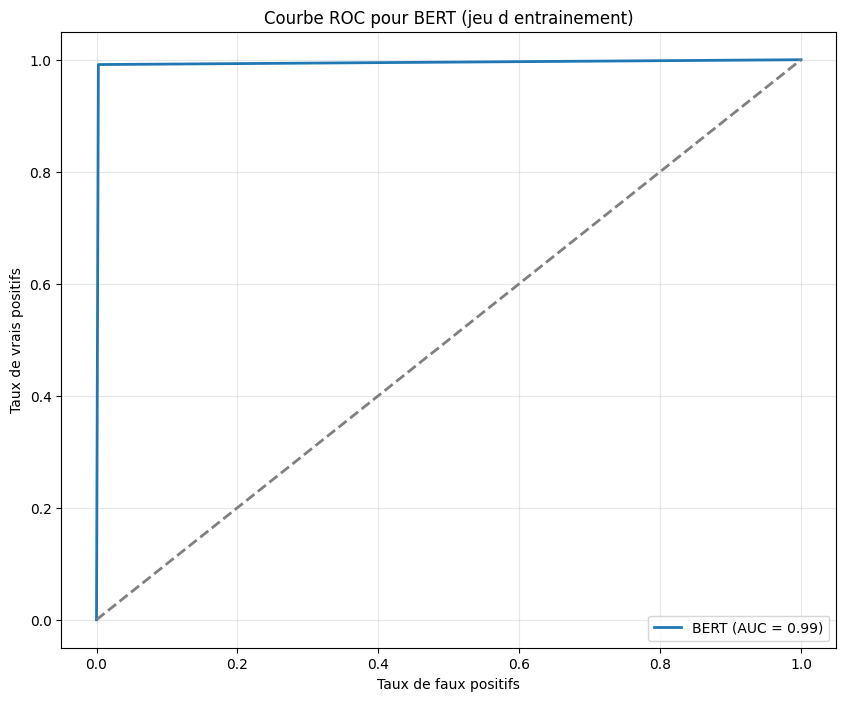

In [106]:

# Calculer la courbe ROC pour BERT
fpr_bert, tpr_bert, _ = roc_curve(y_true_train, y_pred_train)
roc_auc_bert = auc(fpr_bert, tpr_bert)

# Afficher la courbe ROC pour BERT
plt.figure(figsize=(10, 8))
plt.plot(fpr_bert, tpr_bert, lw=2, label=f'BERT (AUC = {roc_auc_bert:.2f})')
plt.plot([0, 1], [0, 1], '--', color='gray', lw=2)
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC pour BERT (jeu d entrainement)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

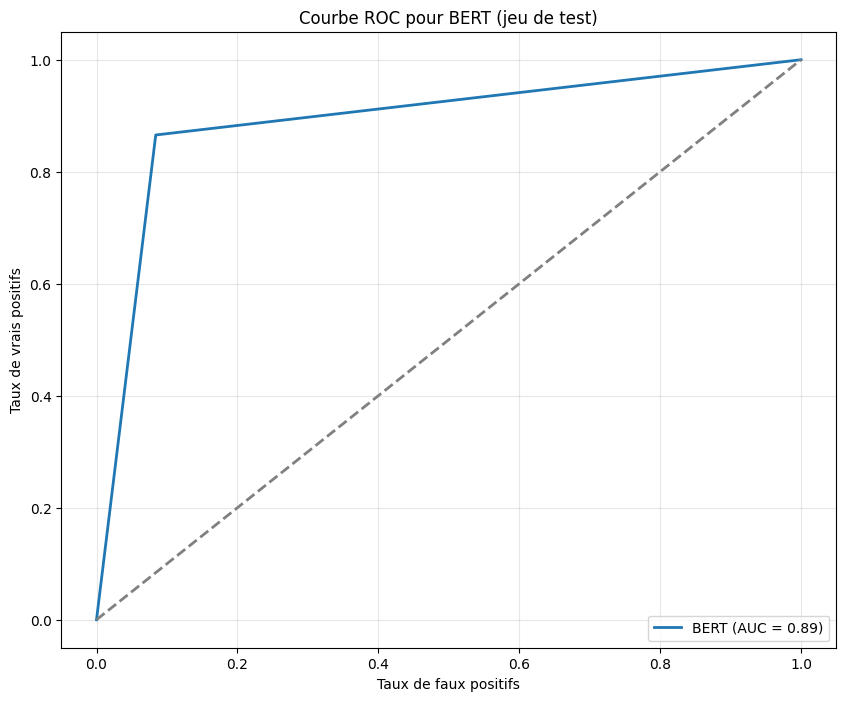

In [107]:
# Calculer la courbe ROC pour BERT
fpr_bert, tpr_bert, _ = roc_curve(y_true, y_pred_test)
roc_auc_bert = auc(fpr_bert, tpr_bert)

# Afficher la courbe ROC pour BERT
plt.figure(figsize=(10, 8))
plt.plot(fpr_bert, tpr_bert, lw=2, label=f'BERT (AUC = {roc_auc_bert:.2f})')
plt.plot([0, 1], [0, 1], '--', color='gray', lw=2)
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC pour BERT (jeu de test)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

#### <span style="color:green; font-size:1em; font-weight:bold;"> Commentaire</span>
L’AUC test de 0,89 est cohérente avec le F1-score de 0,8879, mais la précision (0,9115) et le rappel (0,8656) montrent que BERT excelle dans l’identification des positifs tout en manquant quelques cas.

Comparaison avec TF-IDF et Word2Vec : L’AUC test de 0,89 est inférieur à TF-IDF (0,95) et Word2Vec (0,91), indiquant que BERT ne tire pas pleinement parti de ses capacités contextuelles dans cette configuration, possiblement en raison d’un surapprentissage ou d’un réglage suboptimal.